# Kestrel routing:
**1. What I tried** · **2. What I changed** · **3. What I threw away**

In [39]:
import sys, warnings; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from kestrel_router import data as D, evaluate as E, features as F
from kestrel_router.model import build
from kestrel_router.plotting import use_style, BLUE, ORANGE, GREY

use_style(); pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"font.size": 13, "axes.titlesize": 15})
df = D.load_train()

def bars(ax, labels, values, title, colors=None, fmt="{:.0%}", xmax=None):
    colors = colors or [BLUE] * len(values)
    ax.barh(labels, values, color=colors, height=0.6)
    ax.invert_yaxis(); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, xmax or max(values) * 1.25); ax.set_xticks([])
    for i, v in enumerate(values):
        ax.text(v, i, "  " + fmt.format(v), va="center", fontsize=13, fontweight="bold")
    ax.set_title(title, loc="left")

## 1 · What I tried: looking at the data

In [40]:
df[(df.team_label != df.final_team) & (df.transfers > 0)].head(2)

,request_id,created_at_ist,channel,product_family,warranty_status,request_text,source,team_label,first_team,final_team,transfers,resolved_at,created_at,text_clean,impossible,pingpong
2,SR500002,2025-04-01 03:26,whatsapp,Water Purifier,in_warranty,claim status for purifier under warranty paid by emi very disappointed Ã¢â‚¬Â¦,legacy_zoho,Billing,Billing,Warranty Claims,1,2025-04-01 13:26,2025-04-01 03:26:00,claim status for purifier under warranty paid by emi very disappointed ...,False,False
8,SR500008,2025-04-01 09:59,ivr,Induction Cooktop,in_warranty,sir is induction cooktop covered under shield plan already paid in full thanks,legacy_zoho,Billing,Billing,Warranty Claims,1,2025-04-01 16:38,2025-04-01 09:59:00,sir is induction cooktop covered under shield plan already paid in full thanks,False,False


In [41]:
df[(df.team_label == df.final_team) & (df.transfers > 0)].shape

(351, 16)

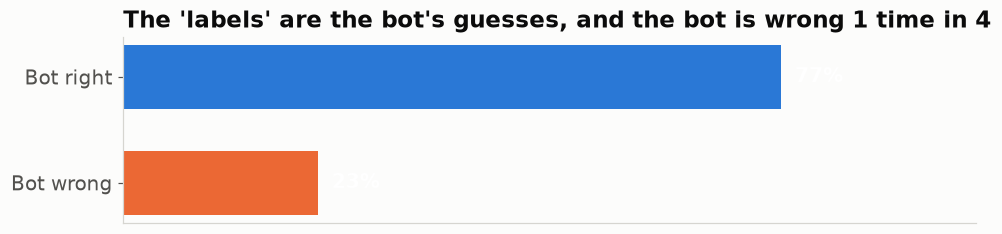

In [42]:
bot_right = (df.team_label == df.final_team).mean()
fig, ax = plt.subplots(figsize=(10, 2.2))
bars(ax, ["Bot right", "Bot wrong"], [bot_right, 1 - bot_right],
     "The 'labels' are the bot's guesses, and the bot is wrong 1 time in 4", [BLUE, ORANGE], xmax=1)
plt.show()

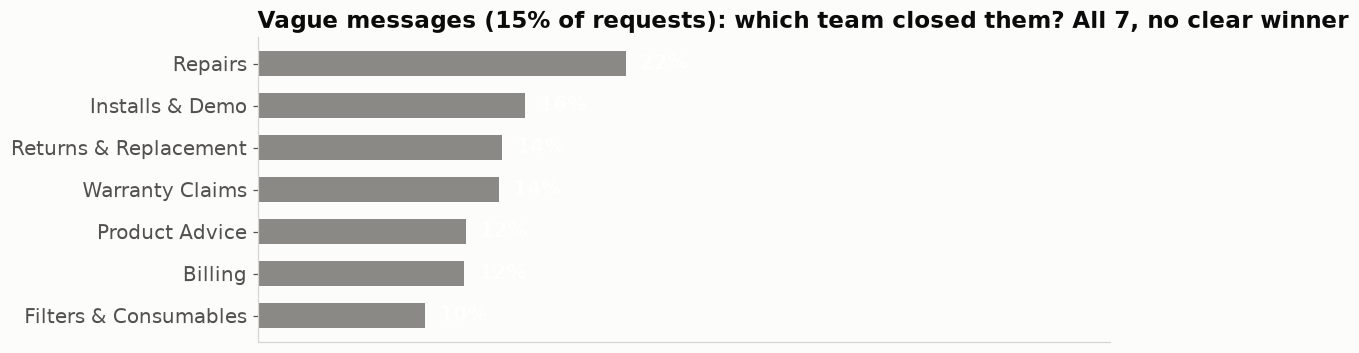

In [43]:
df["vague"] = df.text_clean.map(F.is_vague)
v = df[df.vague].final_team.value_counts(normalize=True)
fig, ax = plt.subplots(figsize=(10, 3.6))
bars(ax, list(v.index), list(v.values),
     f"Vague messages ({df.vague.mean():.0%} of requests): which team closed them? All 7, no clear winner", [GREY] * len(v), xmax=0.5)
plt.show()

In [44]:
ex = df[df.vague].drop_duplicates("final_team").head(5)
pd.DataFrame({"Customer wrote": ex.request_text.map(D.mask_ids).values, "Closed by": ex.final_team.values})

,Customer wrote,Closed by
0,"namaste, please call back regarding ceiling fan very disappointed",Product Advice
1,pls help - service request for purifier thanks,Warranty Claims
2,"good morning, complaint about mixer grinder very disappointed",Repairs
3,"hello team, robot vacuum query order [id]",Billing
4,need help with my robot vacuum reg no [id],Installs & Demo


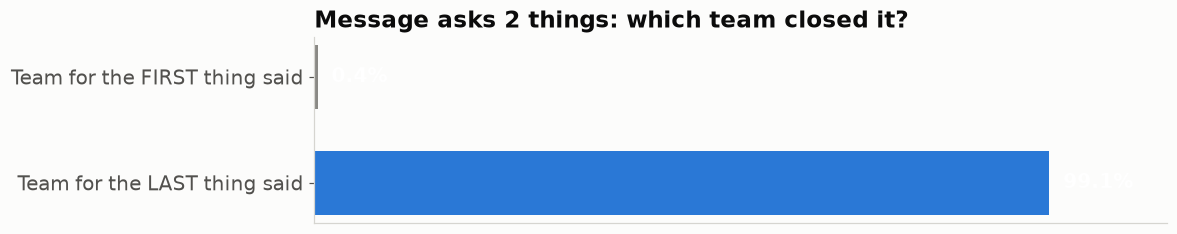

In [45]:
def parts(t): return [F.shape(p) for p in F.content_clauses(t)]
shapes = df.text_clean.map(F.shape)
g = df.groupby(shapes).final_team.agg(lambda s: s.value_counts(normalize=True).iloc[0])
team_of = df[shapes.isin(g[g > 0.9].index)].groupby(shapes).final_team.agg(lambda s: s.value_counts().index[0])
two = df[df.text_clean.map(lambda t: len(parts(t)) == 2)].copy()
two["first"] = two.text_clean.map(lambda t: team_of.get(parts(t)[0]))
two["last"] = two.text_clean.map(lambda t: team_of.get(parts(t)[1]))
two = two.dropna(subset=["first", "last"]); two = two[two["first"] != two["last"]]
fig, ax = plt.subplots(figsize=(10, 2.2))
bars(ax, ["Team for the FIRST thing said", "Team for the LAST thing said"],
     [(two.final_team == two["first"]).mean(), (two.final_team == two["last"]).mean()],
     "Message asks 2 things: which team closed it?", [GREY, BLUE], fmt="{:.1%}", xmax=1.15)
plt.show()

In [46]:
ex = two.drop_duplicates(["first", "last"]).head(5)
pd.DataFrame({"Customer wrote": ex.request_text.map(D.mask_ids).values, "First thing → team": ex["first"].values,
              "Last thing → team": ex["last"].values, "Actually closed by": ex.final_team.values})

,Customer wrote,First thing → team,Last thing → team,Actually closed by
0,"urgent: ceiling fan making loud noise, power consumption of ceiling fan reg no [id]",Repairs,Product Advice,Product Advice
1,"power consumption of ceiling fan, ceiling fan making loud noise paid on upi very disap...",Product Advice,Repairs,Repairs
2,"is room heater covered under shield plan, motor of room heater burnt smell thanks",Warranty Claims,Repairs,Repairs
3,"return pickup for water purifier not done, need warranty certificate water purifier th...",Returns & Replacement,Warranty Claims,Warranty Claims
4,"hi, brush roll spare for air fryer, wrong model of air fryer delivered",Filters & Consumables,Returns & Replacement,Returns & Replacement


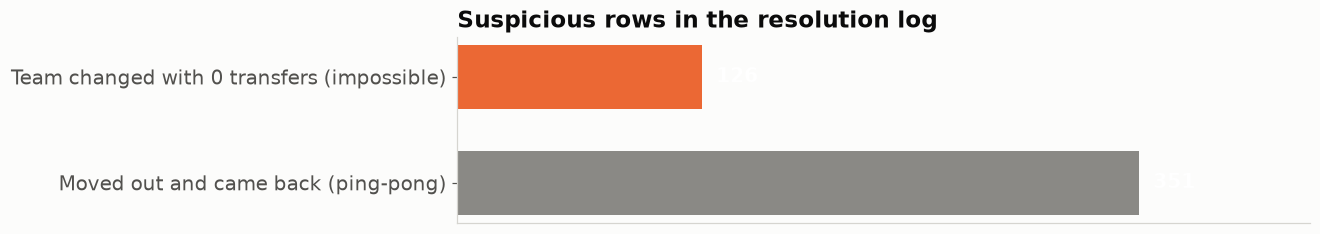

In [47]:
fig, ax = plt.subplots(figsize=(10, 2.2))
bars(ax, ["Team changed with 0 transfers (impossible)", "Moved out and came back (ping-pong)"],
     [int(df.impossible.sum()), int(df.pingpong.sum())], "Suspicious rows in the resolution log", [ORANGE, GREY], fmt="{:,}")
plt.show()

**Impossible rows:** the team changed but 0 transfers were recorded, and the final team often contradicts the message.

In [48]:
ex = df[df.impossible].head(5)
pd.DataFrame({"Customer wrote": ex.request_text.map(D.mask_ids).values, "Bot sent to": ex.first_team.values,
              "Recorded as closed by": ex.final_team.values, "Transfers": ex.transfers.values})

,Customer wrote,Bot sent to,Recorded as closed by,Transfers
0,need warranty certificate mixer grinder order [id],Warranty Claims,Repairs,0
1,difference between lite and pro room heater kindly resolve,Product Advice,Warranty Claims,0
2,pls help - induction cooktop leaking water from bottom,Repairs,Product Advice,0
3,"namaste, installer did not turn up for robot vacuum kindly resolve",Installs & Demo,Repairs,0
4,extend warranty for mixer grinder asap,Warranty Claims,Repairs,0


**Ping-pong rows:** the bot was right, an agent moved it away, and it came back.

In [49]:
ex = df[df.pingpong].head(5)
pd.DataFrame({"Customer wrote": ex.request_text.map(D.mask_ids).values, "Bot sent to": ex.first_team.values,
              "Closed by": ex.final_team.values, "Transfers": ex.transfers.values})

,Customer wrote,Bot sent to,Closed by,Transfers
0,"hi, display of air fryer gone blank thanks",Repairs,Repairs,1
1,"hi, invoice not received for induction cooktop",Billing,Billing,1
2,"hello team, shield plan renewal for vacuum",Warranty Claims,Warranty Claims,1
3,need warranty certificate purifier pls call back,Warranty Claims,Warranty Claims,1
4,spare blade set for induction cooktop available?,Filters & Consumables,Filters & Consumables,1


## 2 · What I changed: target, features, model

In [50]:
train, ev = D.time_split(df, *D.HOLDOUT)          # train: Apr 2025 – Mar 2026 · test: Apr – Jun 2026
acc = lambda p: float(np.mean(p == ev.final_team))

copy_bot = build("logreg").fit(train, train.team_label).predict(ev)
results = {"Vendor bot": acc(ev.team_label), "Model trained on the bot's labels": acc(copy_bot)}
fit_s = {}
for name in ["nb", "lgbm", "linsvm", "logreg"]:
    r = E.run_fold(name, df, D.HOLDOUT)
    results[name], fit_s[name] = acc(r.frame.pred), r.fit_seconds
final = E.run_fold("logreg", df, D.HOLDOUT, policy=True, drop_bad=True).frame
results["logreg + policy features (final)"] = acc(final.pred)

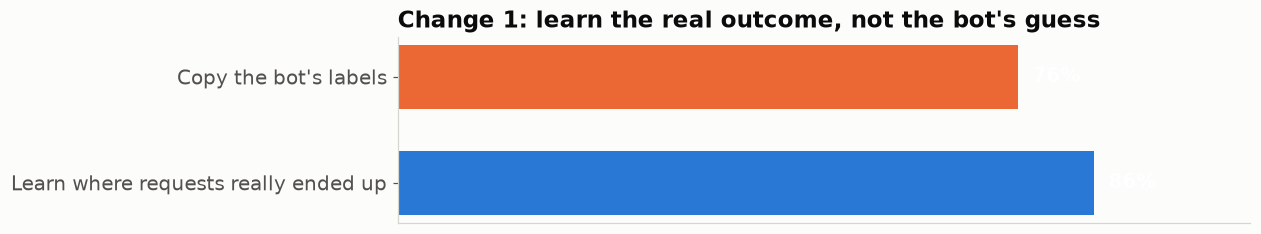

In [51]:
fig, ax = plt.subplots(figsize=(10, 2.2))
bars(ax, ["Copy the bot's labels", "Learn where requests really ended up"],
     [results["Model trained on the bot's labels"], results["logreg + policy features (final)"]],
     "Change 1: learn the real outcome, not the bot's guess", [ORANGE, BLUE], xmax=1.05)
plt.show()

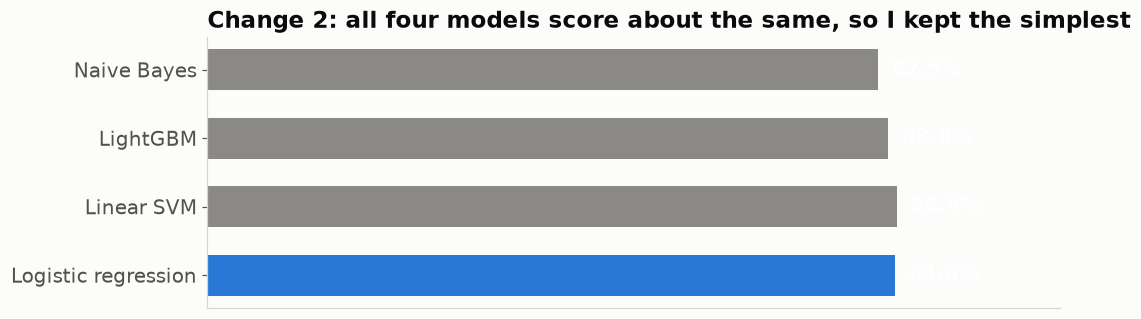

In [52]:
names = {"nb": "Naive Bayes", "lgbm": "LightGBM", "linsvm": "Linear SVM", "logreg": "Logistic regression"}
fig, ax = plt.subplots(figsize=(10, 3.2))
bars(ax, list(names.values()), [results[k] for k in names],
     "Change 2: all four models score about the same, so I kept the simplest", [GREY, GREY, GREY, BLUE], fmt="{:.1%}", xmax=1.05)
plt.show()

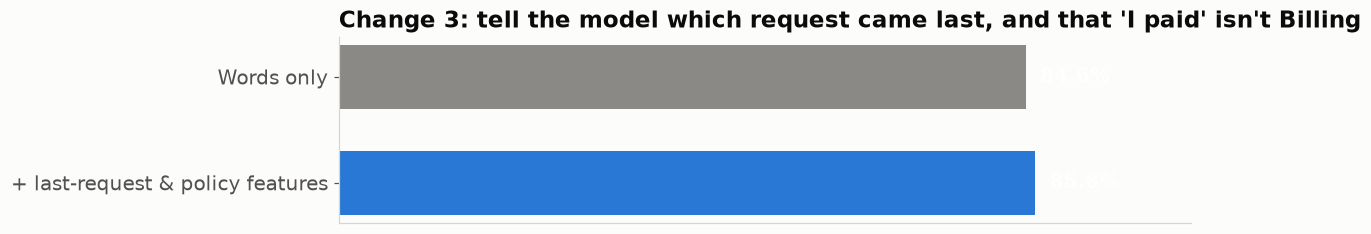

In [53]:
fig, ax = plt.subplots(figsize=(10, 2.2))
bars(ax, ["Words only", "+ last-request & policy features"], [results["logreg"], results["logreg + policy features (final)"]],
     "Change 3: tell the model which request came last, and that 'I paid' isn't Billing", [GREY, BLUE], fmt="{:.1%}", xmax=1.05)
plt.show()

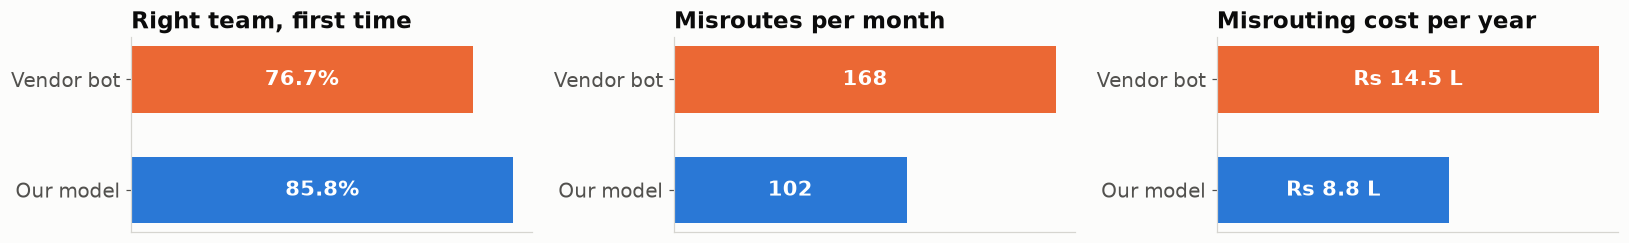

Saving ≈ Rs 8.9 lakh a year (Rs 5.7 lakh fewer misroutes + Rs 3.2 lakh licence) · run cost Rs 0


In [58]:
per_month = lambda a: (1 - a) * E.REQUESTS_PER_MONTH
M = E.misroute_cost(df)
bot_acc, our_acc = results["Vendor bot"], results["logreg + policy features (final)"]
bot_m, our_m = per_month(bot_acc), per_month(our_acc)
bot_year, our_year = bot_m * M * 12 / 1e5, our_m * M * 12 / 1e5
saving = (bot_year - our_year) + E.LICENCE_RS_YEAR / 1e5

fig, axes = plt.subplots(1, 3, figsize=(15, 2.4))
panels = [([bot_acc, our_acc], ["{:.1%}"] * 2, "Right team, first time"),
          ([bot_m, our_m], ["{:.0f}"] * 2, "Misroutes per month"),
          ([bot_year, our_year], ["Rs {:.1f} L"] * 2, "Misrouting cost per year")]
for ax, (vals, fmts, title) in zip(axes, panels):
    b = ax.barh(["Vendor bot", "Our model"], vals, color=[ORANGE, BLUE], height=0.6)
    ax.bar_label(b, labels=[f.format(v) for f, v in zip(fmts, vals)], label_type="center",
                 color="white", fontsize=14, fontweight="bold")
    ax.invert_yaxis(); ax.set_xticks([]); ax.grid(False); ax.set_title(title, loc="left")
plt.tight_layout(); plt.show()
print(f"Saving ≈ Rs {saving:.1f} lakh a year (Rs {bot_year - our_year:.1f} lakh fewer misroutes + Rs 3.2 lakh licence) · run cost Rs 0")

## 3 · What I threw away

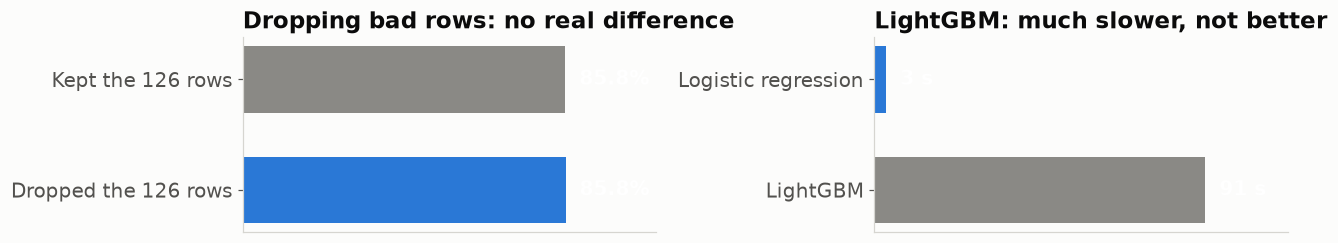

In [55]:
no_drop = E.run_fold("logreg", df, D.HOLDOUT, policy=True, drop_bad=False).frame
fig, axes = plt.subplots(1, 2, figsize=(12, 2.4))
bars(axes[0], ["Kept the 126 rows", "Dropped the 126 rows"], [acc(no_drop.pred), acc(final.pred)],
     "Dropping bad rows: no real difference", [GREY, BLUE], fmt="{:.1%}", xmax=1.1)
bars(axes[1], ["Logistic regression", "LightGBM"], [fit_s["logreg"], fit_s["lgbm"]],
     "LightGBM: much slower, not better", [BLUE, GREY], fmt="{:.0f} s")
plt.tight_layout(); plt.show()

| Thrown away | Why |
|---|---|
| Copying the bot's labels | Hits 90%+ "match", but no better than the bot |
| LightGBM, Naive Bayes | Not better than logistic regression |
| A fixed team for vague requests | Helped one quarter, hurt the latest |
| An LLM | Needs a paid key and sends customer text outside (policy §10); can't fix messages that say nothing |